**Data Inspection Introduction**

Before cleaning or training any model, the CFD dataset must be inspected to confirm that it is valid, complete, and aligned with the research methodology. The dataset was exported from OpenFOAM/ParaView and contains spatial coordinates, velocity components, and pressure values for two dimensional flow around a cylinder. This inspection checks the dataset size, column structure, missing values, numerical ranges, two dimensional consistency, and basic flow-field visualization.

In [3]:

# CFD DATA INSPECTION
# Project: Hybrid Adaptive PINN for 2D Cylinder Flow Prediction
# Purpose: Understand the exported OpenFOAM dataset before cleaning

# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt


# STEP 1: Load the CFD dataset

# Change the file name if your CSV file has a slightly different name
file_path = "/content/CFD  - 2D flow.csv"

df = pd.read_csv(file_path)

# Display the first 10 rows
print("First 10 rows of the dataset:")
display(df.head(10))


First 10 rows of the dataset:


,Points:0,Points:1,Points:2,U:0,U:1,U:2,p
0,0.000500,0.0,-0.0005,0.000000e+00,0.000000e+00,0.000000e+00,-0.00062
1,0.000500,0.0,-0.0005,2.542700e-10,1.285000e-07,0.000000e+00,-0.00062
2,0.000501,0.0,-0.0005,3.686500e-10,1.859700e-07,0.000000e+00,-0.00062
3,0.000501,0.0,-0.0005,7.044800e-10,2.305500e-07,-5.079300e-29,-0.00062
4,0.000502,0.0,-0.0005,1.129000e-09,2.857700e-07,2.947200e-26,-0.00062
5,0.000502,0.0,-0.0005,1.688300e-09,3.541700e-07,-3.320500e-27,-0.00062
6,0.000503,0.0,-0.0005,2.454300e-09,4.388700e-07,-3.298300e-26,-0.00062
7,0.000504,0.0,-0.0005,3.501100e-09,5.437300e-07,-1.398600e-28,-0.00062
8,0.000504,0.0,-0.0005,4.927800e-09,6.734900e-07,0.000000e+00,-0.00062
9,0.000505,0.0,-0.0005,6.870200e-09,8.340300e-07,-5.056600e-26,-0.00062


In [4]:
# STEP 2: Check dataset size
print("\nDataset size:")
print("Dataset shape:")
print(df.shape)

print("\nInterpretation:")
print("Rows represent spatial data points in the CFD domain.")
print("Columns represent coordinates, velocity components, and pressure.")


Dataset size:
Dataset shape:
(15254, 7)

Interpretation:
Rows represent spatial data points in the CFD domain.
Columns represent coordinates, velocity components, and pressure.


In [5]:
# STEP 3: Check column names

print("Column names in the dataset:")
print(df.columns.tolist())

print("\nExpected raw OpenFOAM/ParaView columns:")
print(["Points:0", "Points:1", "Points:2", "U:0", "U:1", "U:2", "p"])

Column names in the dataset:
['Points:0', 'Points:1', 'Points:2', 'U:0', 'U:1', 'U:2', 'p']

Expected raw OpenFOAM/ParaView columns:
['Points:0', 'Points:1', 'Points:2', 'U:0', 'U:1', 'U:2', 'p']


In [6]:
# STEP 4: Check data types

print("Data types:")
print(df.dtypes)

print("\nAll columns should ideally be numerical, usually float64.")

Data types:
Points:0    float64
Points:1    float64
Points:2    float64
U:0         float64
U:1         float64
U:2         float64
p           float64
dtype: object

All columns should ideally be numerical, usually float64.


In [7]:
# STEP 5: Check missing values

print("Missing values in each column:")
print(df.isnull().sum())

print("\nIf all values are zero, the dataset has no missing values.")

Missing values in each column:
Points:0    0
Points:1    0
Points:2    0
U:0         0
U:1         0
U:2         0
p           0
dtype: int64

If all values are zero, the dataset has no missing values.


In [8]:
# STEP 6: Basic statistical summary

print("Statistical summary of the dataset:")
display(df.describe())

print("\nThis helps identify the minimum, maximum, mean, and spread of each variable.")

Statistical summary of the dataset:


,Points:0,Points:1,Points:2,U:0,U:1,U:2,p
count,15254.000000,1.525400e+04,15254.0000,1.525400e+04,1.525400e+04,1.525400e+04,15254.000000
mean,0.010062,6.246042e-03,0.0000,4.454733e-03,-2.573395e-05,-8.752079e-23,0.000024
std,0.022813,1.423900e-02,0.0005,5.415735e-03,7.590892e-04,1.827450e-20,0.000591
min,-0.100000,-5.989100e-18,-0.0005,-3.291500e-05,-2.287700e-02,-5.219800e-19,-0.002441
25%,-0.000150,3.576000e-04,-0.0005,-5.930150e-10,-1.041725e-05,-7.210050e-24,-0.000309
50%,0.000545,8.045200e-04,0.0000,2.180800e-03,1.182300e-09,0.000000e+00,0.000077
75%,0.011601,5.459300e-03,0.0005,7.156425e-03,9.136025e-06,6.370200e-24,0.000250
max,0.100000,1.000000e-01,0.0005,1.834100e-02,1.883200e-03,5.721000e-19,0.002610



This helps identify the minimum, maximum, mean, and spread of each variable.


In [9]:
# STEP 7: Confirm whether the dataset is effectively 2D

max_z_coordinate = df["Points:2"].abs().max()
max_z_velocity = df["U:2"].abs().max()

print("Maximum absolute z-coordinate value:", max_z_coordinate)
print("Maximum absolute z-velocity value:", max_z_velocity)

print("\nInterpretation:")
print("If these values are extremely close to zero, the dataset is effectively two dimensional.")

Maximum absolute z-coordinate value: 0.0005
Maximum absolute z-velocity value: 5.721e-19

Interpretation:
If these values are extremely close to zero, the dataset is effectively two dimensional.


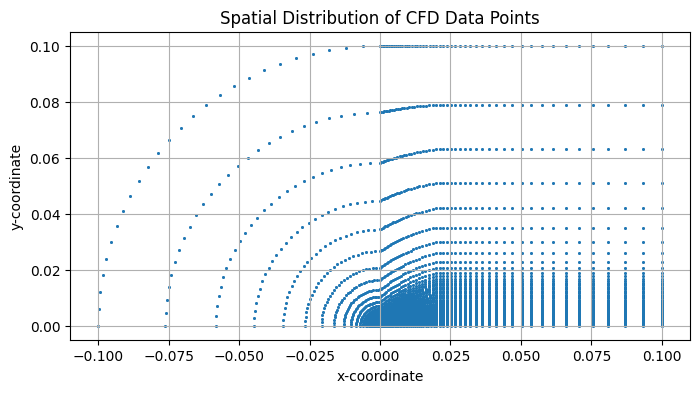

This plot shows the geometry of the CFD domain and the spatial distribution of points.


In [10]:
# STEP 8: Plot spatial distribution of CFD points

plt.figure(figsize=(8, 4))
plt.scatter(df["Points:0"], df["Points:1"], s=1)
plt.title("Spatial Distribution of CFD Data Points")
plt.xlabel("x-coordinate")
plt.ylabel("y-coordinate")
plt.grid(True)
plt.show()

print("This plot shows the geometry of the CFD domain and the spatial distribution of points.")

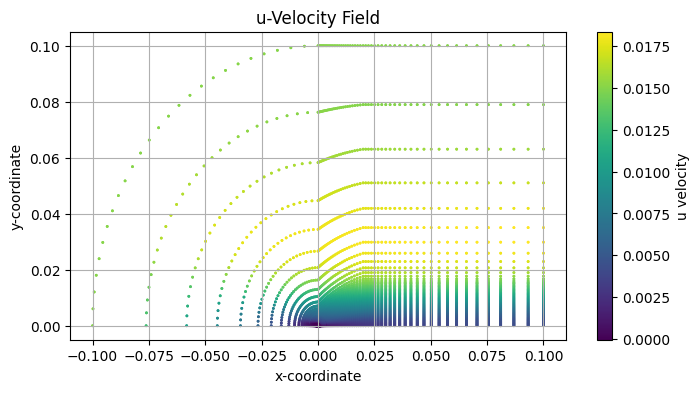

This plot shows the horizontal velocity component across the flow domain.


In [11]:
# STEP 9: Plot u-velocity field

plt.figure(figsize=(8, 4))
plt.scatter(df["Points:0"], df["Points:1"], c=df["U:0"], s=1)
plt.colorbar(label="u velocity")
plt.title("u-Velocity Field")
plt.xlabel("x-coordinate")
plt.ylabel("y-coordinate")
plt.grid(True)
plt.show()

print("This plot shows the horizontal velocity component across the flow domain.")

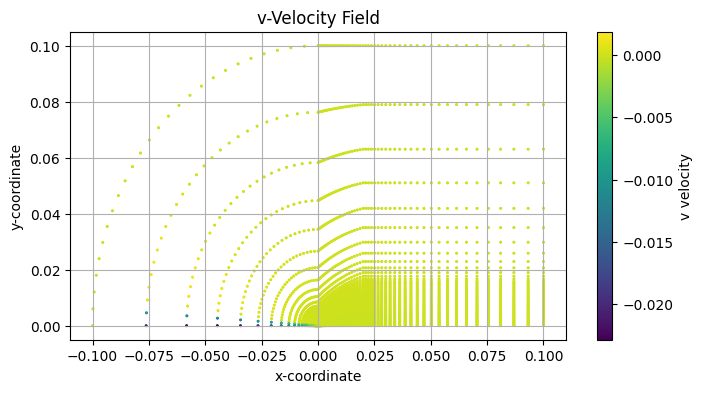

This plot shows the vertical velocity component, which helps reveal flow deflection and wake behavior.


In [12]:
# STEP 10: Plot v-velocity field

plt.figure(figsize=(8, 4))
plt.scatter(df["Points:0"], df["Points:1"], c=df["U:1"], s=1)
plt.colorbar(label="v velocity")
plt.title("v-Velocity Field")
plt.xlabel("x-coordinate")
plt.ylabel("y-coordinate")
plt.grid(True)
plt.show()

print("This plot shows the vertical velocity component, which helps reveal flow deflection and wake behavior.")

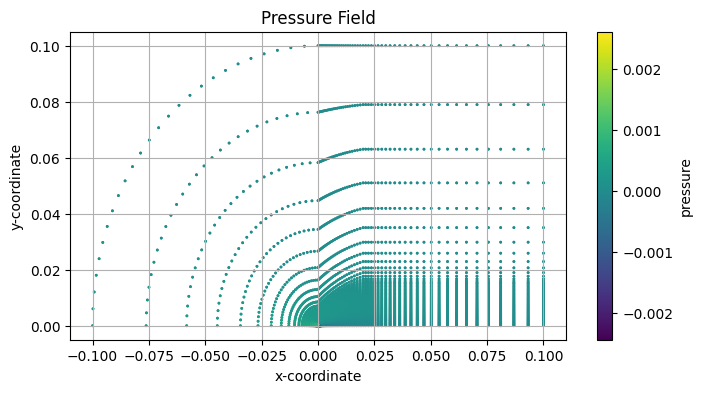

This plot shows pressure variation around the cylinder and wake region.


In [13]:
# STEP 11: Plot pressure field

plt.figure(figsize=(8, 4))
plt.scatter(df["Points:0"], df["Points:1"], c=df["p"], s=1)
plt.colorbar(label="pressure")
plt.title("Pressure Field")
plt.xlabel("x-coordinate")
plt.ylabel("y-coordinate")
plt.grid(True)
plt.show()

print("This plot shows pressure variation around the cylinder and wake region.")

In [14]:
# STEP 12: Compute velocity magnitude

df["velocity_magnitude"] = (df["U:0"]**2 + df["U:1"]**2)**0.5

print("Velocity magnitude added as a temporary inspection variable.")
display(df[["U:0", "U:1", "velocity_magnitude"]].head())

Velocity magnitude added as a temporary inspection variable.


,U:0,U:1,velocity_magnitude
0,0.000000e+00,0.000000e+00,0.000000e+00
1,2.542700e-10,1.285000e-07,1.285003e-07
2,3.686500e-10,1.859700e-07,1.859704e-07
3,7.044800e-10,2.305500e-07,2.305511e-07
4,1.129000e-09,2.857700e-07,2.857722e-07


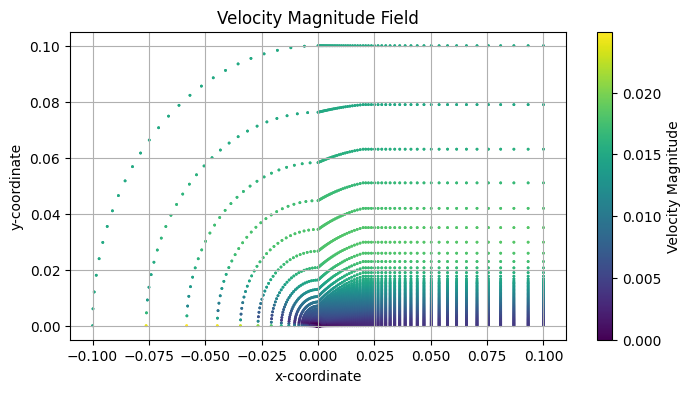

This plot helps identify flow acceleration, low-velocity wake regions, and near-cylinder effects.


In [15]:
# STEP 13: Plot velocity magnitude

plt.figure(figsize=(8, 4))
plt.scatter(df["Points:0"], df["Points:1"], c=df["velocity_magnitude"], s=1)
plt.colorbar(label="Velocity Magnitude")
plt.title("Velocity Magnitude Field")
plt.xlabel("x-coordinate")
plt.ylabel("y-coordinate")
plt.grid(True)
plt.show()

print("This plot helps identify flow acceleration, low-velocity wake regions, and near-cylinder effects.")

In [16]:
# STEP 14: Final inspection summary

print("CFD DATA INSPECTION SUMMARY")
print("--------------------------------")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Missing values:", df.isnull().sum().sum())
print("Maximum absolute Points:2:", max_z_coordinate)
print("Maximum absolute U:2:", max_z_velocity)
print("Minimum pressure:", df["p"].min())
print("Maximum pressure:", df["p"].max())
print("Minimum velocity magnitude:", df["velocity_magnitude"].min())
print("Maximum velocity magnitude:", df["velocity_magnitude"].max())

print("\nConclusion:")
print("If the z-coordinate and z-velocity are close to zero, the dataset is suitable for 2D modelling.")
print("The next step after inspection is data cleaning and preparation.")

CFD DATA INSPECTION SUMMARY
--------------------------------
Number of rows: 15254
Number of columns: 8
Missing values: 0
Maximum absolute Points:2: 0.0005
Maximum absolute U:2: 5.721e-19
Minimum pressure: -0.0024414
Maximum pressure: 0.0026099
Minimum velocity magnitude: 0.0
Maximum velocity magnitude: 0.024927093954169626

Conclusion:
If the z-coordinate and z-velocity are close to zero, the dataset is suitable for 2D modelling.
The next step after inspection is data cleaning and preparation.


In [17]:
df["Points:2"].unique()


array([-0.0005,  0.0005])

The result array([-0.0005, 0.0005]) indicates that the z-coordinate in the dataset takes only two constant values, representing a very thin computational thickness used by OpenFOAM to model a two-dimensional flow problem within a three-dimensional framework. This means that the simulation is effectively a 2D flow around a cylinder, but implemented as a thin 3D slab for numerical stability. Since the velocity component in the z-direction is negligible, the flow exhibits no variation along the z-axis, confirming that the physical behavior is purely two-dimensional. Consequently, the z-dimension does not contribute meaningful information for machine learning and can be safely removed during data preprocessing to ensure that the model focuses only on the relevant spatial dimensions (x and y) and their corresponding velocity and pressure fields.

**Conclusion of Data Inspection**

The CFD dataset generated from OpenFOAM was successfully inspected and verified for quality, consistency, and suitability for machine learning applications. The dataset contains 15,254 spatial data points with no missing values, confirming its completeness and reliability for further analysis. All variables were identified as numerical, ensuring compatibility with data-driven and physics-informed modeling approaches.

The dataset includes spatial coordinates, velocity components, and pressure values representing the flow field around a cylinder. Although the data is stored in a three-dimensional format, inspection revealed that the z-coordinate consists of two constant values forming a thin computational layer, while the velocity component in the z-direction is effectively zero. This confirms that the dataset represents a two-dimensional flow problem, consistent with the research objective.

Statistical analysis and visualization of the velocity and pressure fields demonstrated physically meaningful behavior, including flow acceleration around the cylinder, pressure variation at the stagnation region, and the presence of a wake region downstream. These features indicate that the dataset captures the nonlinear flow characteristics required for evaluating both physics-informed and data-driven models.

Overall, the dataset is clean, physically valid, and aligned with the approved research methodology. It provides a reliable foundation for subsequent data cleaning, preprocessing, and model development stages. The next step involves preparing the dataset by restructuring variables, removing unnecessary dimensions, and normalizing the data for machine learning implementation.